In [1]:
import math
from pathlib import Path
import cvxpy as cp
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt
from joblib import Parallel, delayed, cpu_count

from mis_dro.dataset import *
from mis_dro.likelihood import sample_likelihood
from mis_dro.kl_divergence import kl_divergence_monte_carlo
from mis_dro.bayes_conjugates import *
from mis_dro.plot import *
import matplotlib as mpl

from matplotlib import rc
rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], "size":14})
rc('text', usetex=True)

In [2]:
replication = 0
dataset = "newsvendor"
dgp = "normal"
likelihood = "normal"
posterior = "normal_gamma"
num_observations = 20
num_test_observations = 200
num_likelihood_samples = 50
num_posterior_samples = 5
epsilon = 0.2
dim = 1
contamination = 0.0
generator = np.random.default_rng(seed=replication)

In [3]:
data = sample_dgp(
    dgp, num_observations, dim=dim, contamination=contamination, generator=generator
)
data_eval = sample_dgp(
    dgp, num_test_observations, dim=dim, contamination=0.0, generator=generator
)

In [4]:
theta_prior = default_prior_params(posterior, dim=dim)
mu_prior, kappa_prior, alpha_prior, beta_prior = 0.0, 1.0, 5, 0.01
theta_prior = (mu_prior, kappa_prior, alpha_prior, beta_prior)
theta_posterior = get_posterior_params(posterior, data, theta_prior)
bas_sample = derive_analytical_posterior_params(
    posterior, theta_posterior
)
bdro_sample = normal_gamma_rvs(num_posterior_samples, *theta_posterior, generator=generator)


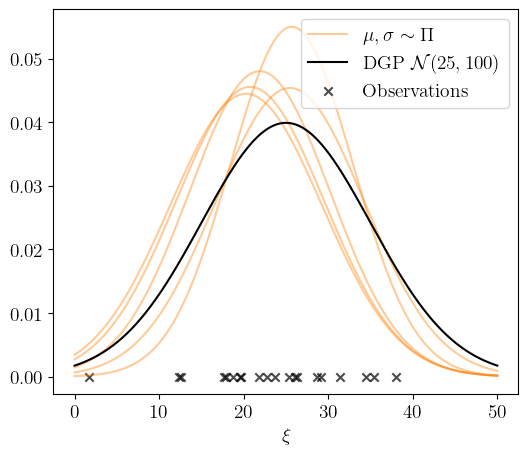

In [5]:
fig, ax = plt.subplots(figsize=(6,5))
x = np.linspace(0,50,1000)
dgp_mean = 25.0
dgp_std = 10.0
for i in range(num_posterior_samples):
    if i == 0:
        label="$\mu, \sigma \sim \Pi$"
    else:
        label="_nolegend_"
    ax.plot(x, sp.stats.norm.pdf(x, loc=bdro_sample[i,0],scale=bdro_sample[i,1]), label=label, color=AlgorithmColor.kl_bdro.value, alpha=0.4)
ax.plot(x, sp.stats.norm.pdf(x, loc=dgp_mean, scale=dgp_std), label="DGP $\mathcal{N}(25, 100)$", color="black")
# ax.plot(x, sp.stats.norm.pdf(x, loc=bas_sample[0,0],scale=bas_sample[0,1]), label="$\mathcal{N}(\hat{\mu}, \hat{\sigma})$", color=AlgorithmColor.kl_dro_bas.value)
ax.scatter(data, np.zeros(num_observations), marker="x", color="black", label="Observations", alpha=0.7)
ax.set_xlabel(r"$\xi$")
ax.legend()
# fig.savefig("/Users/patrick/Experiments/misdro/2025_01_21_paper_bas_experiments/dgp_samples_and_likelihoods.pdf", bbox_inches="tight")

In [6]:
def kl_divergence_1d_normals(mu_1, std_1, mu_2, std_2):
    return np.log(std_2 / std_1) + (std_1**2 + (mu_1 - mu_2)**2) / (2 * std_2**2) - 0.5

def expected_kl_divergence_1d_normals(mu, std, mu_hat, std_hat, G_constant):
    return G_constant + kl_divergence_1d_normals(mu, std, mu_hat, std_hat)

def get_regular_grid(z_samples: np.array, epsilon: float) -> np.array:
    """Get a grid that easily covers the epsilon ball"""
    n_points = 1000
    margin = 0.2
    z_mean = np.mean(z_samples, axis=0)
    x_axis = np.linspace(
        start=min(np.min(z_samples[:, 0]), z_mean[0] - epsilon - margin), 
        stop=max(np.max(z_samples[:, 0]), z_mean[0] + epsilon + margin),
        num=n_points,
    )
    y_axis = np.linspace(
        start=min(np.min(z_samples[:, 1]), z_mean[1] - epsilon - margin),
        stop=max(np.max(z_samples[:, 1]), z_mean[1] + epsilon + margin),
        num=n_points
    )
    xv, yv = np.array(np.meshgrid(x_axis, y_axis))
    return np.array([xv.flatten(), yv.flatten()]).T

In [7]:
z_samples = normal_gamma_rvs(num_posterior_samples, *theta_posterior, generator=generator)
# grid = get_regular_grid(z_samples, epsilon)
xv, yv = np.array(np.meshgrid(np.linspace(15, 35, 1000), np.linspace(0, 20, 1000)))
grid = np.array([xv.flatten(), yv.flatten()]).T
grid.shape

(1000000, 2)

In [8]:
G_constant = get_log_partition_constant(posterior, theta_posterior)
M = np.array([expected_kl_divergence_1d_normals(y[0], y[1], bas_sample[0,0], bas_sample[0,1], G_constant) for y in grid])
in_pe = grid[M <= epsilon]

def get_convex_hull_polygon_points(points):
    hull = sp.spatial.ConvexHull(points)
    return np.array([points[hull.vertices, 0], points[hull.vertices, 1]]).T

bas_convex_hull_points = get_convex_hull_polygon_points(in_pe)


/var/folders/38/gm_d4yxj7bx11rp4p930zwnr0000gn/T/ipykernel_97265/267159308.py:2: RuntimeWarning: divide by zero encountered in scalar divide
  return np.log(std_2 / std_1) + (std_1**2 + (mu_1 - mu_2)**2) / (2 * std_2**2) - 0.5


/var/folders/38/gm_d4yxj7bx11rp4p930zwnr0000gn/T/ipykernel_97265/298153255.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


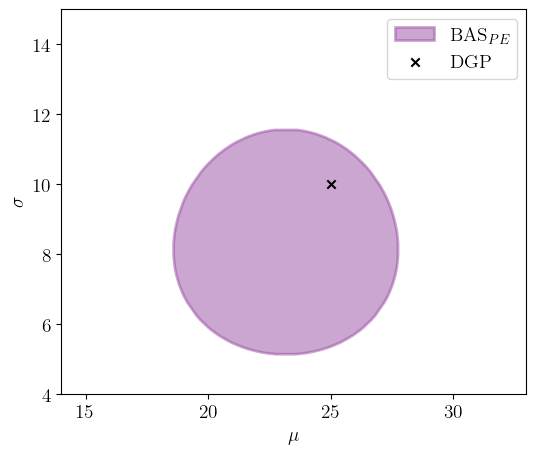

In [9]:
fig, ax = plt.subplots(figsize=(6,5))
# ax.scatter(z_samples[:,0], z_samples[:, 1], alpha=0.3, marker="x")
bas_polygon = mpl.patches.Polygon(bas_convex_hull_points, alpha=0.5, color=AlgorithmColor.kl_dro_bas.value, label="BAS$_{PE}$", closed=True, linewidth=2)
ax.add_patch(bas_polygon)
ax.set_xlabel(r"$\mu$")
ax.set_ylabel(r"$\sigma$")
ax.scatter([dgp_mean], [dgp_std], marker="x", color="black", label="DGP")
ax.set(adjustable="box")
ax.set_xlim(14, 33)
ax.set_ylim(4, 15)
ax.legend()
fig.show()
# fig.savefig("/Users/patrick/Experiments/misdro/2025_01_21_paper_bas_experiments/dro_bas_ambiguity_set.pdf", bbox_inches="tight")

In [10]:
pp_polygon_points = []
pp_params = posterior_predictive_params("normal_gamma", theta_posterior)
mu_pp, scale_pp, df_pp = pp_params[0]
pp_dist = sp.stats.t(df_pp, loc=mu_pp, scale=scale_pp)

def batch_kl_divergence_monte_carlo(grid_points):
    return [kl_divergence_monte_carlo(sp.stats.norm(y[0], y[1]), pp_dist, num_samples=10000, generator=generator) for y in grid_points]

njobs = cpu_count()
assert njobs > 0
pp_kl_samples_list = Parallel(n_jobs=-1)(delayed(batch_kl_divergence_monte_carlo)(batch) for batch in np.array_split(grid, njobs))
pp_kl_samples = np.concatenate(pp_kl_samples_list)
pp_kl_samples.shape


/opt/anaconda3/envs/mis-dro/lib/python3.11/site-packages/scipy/stats/_distn_infrastructure.py:1983: RuntimeWarning: invalid value encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)


(1000000,)

In [11]:
grid[(pp_kl_samples <= epsilon) & (~np.isnan(pp_kl_samples))].shape, np.sum(M <= epsilon)

((171513, 2), 116079)

/var/folders/38/gm_d4yxj7bx11rp4p930zwnr0000gn/T/ipykernel_80317/725636215.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


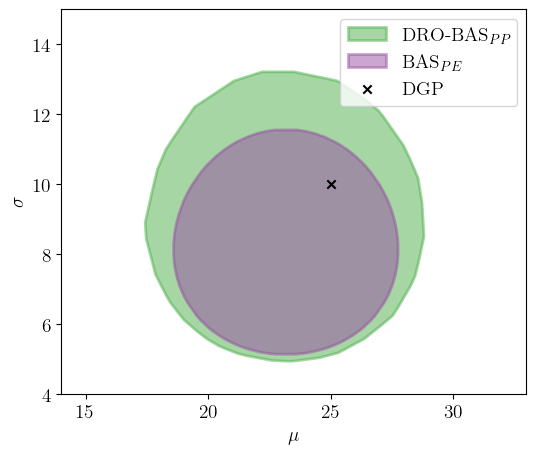

In [12]:
fig, ax = plt.subplots(figsize=(6,5))
in_pp = grid[pp_kl_samples <= epsilon]
pp_convex_hull_points = get_convex_hull_polygon_points(in_pp)
pp_polygon = mpl.patches.Polygon(pp_convex_hull_points, alpha=0.5, color=AlgorithmColor.kl_pp.value, label=AlgorithmName.kl_pp.value, closed=True, linewidth=2)

ax.add_patch(pp_polygon)
bas_polygon = mpl.patches.Polygon(bas_convex_hull_points, alpha=0.5, color=AlgorithmColor.kl_dro_bas.value, label="BAS$_{PE}$", closed=True, linewidth=2)
ax.add_patch(bas_polygon)
ax.set_xlabel(r"$\mu$")
ax.set_ylabel(r"$\sigma$")
ax.scatter([dgp_mean], [dgp_std], marker="x", color="black", label="DGP")
ax.set(adjustable="box")
ax.set_xlim(14, 33)
ax.set_ylim(4, 15)
ax.legend()
fig.show()
# fig.savefig("/Users/patrick/Experiments/misdro/2025_01_21_paper_bas_experiments/bas_pp_ambiguity_set.pdf", bbox_inches="tight")

In [13]:
bdro_polygon_points = []
for point in z_samples:
    M = np.array([kl_divergence_1d_normals(y[0], y[1], point[0], point[1]) for y in grid])
    in_pe = grid[M <= epsilon]
    bdro_polygon_points.append(get_convex_hull_polygon_points(in_pe))


/var/folders/38/gm_d4yxj7bx11rp4p930zwnr0000gn/T/ipykernel_80317/267159308.py:2: RuntimeWarning: divide by zero encountered in scalar divide
  return np.log(std_2 / std_1) + (std_1**2 + (mu_1 - mu_2)**2) / (2 * std_2**2) - 0.5


/var/folders/38/gm_d4yxj7bx11rp4p930zwnr0000gn/T/ipykernel_80317/464630975.py:38: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


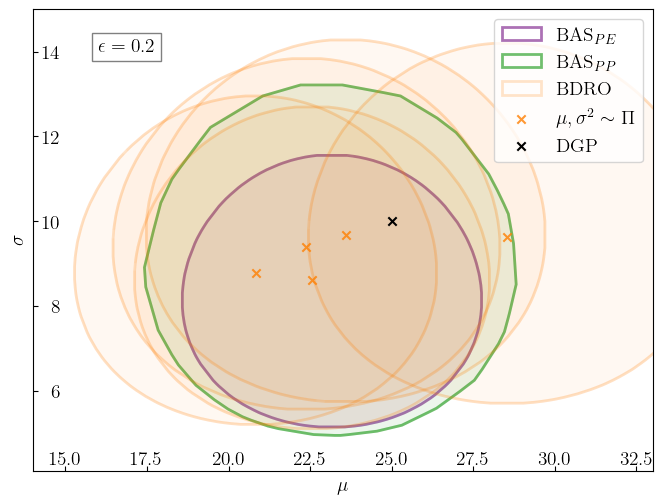

In [ ]:
fig, ax = plt.subplots(figsize=(8,6))

bas_polygon = mpl.patches.Polygon(bas_convex_hull_points,  alpha=0.8, color=AlgorithmColor.kl_dro_bas.value, fill=False, label="BAS$_{PE}$", closed=True, linewidth=2)
bas_polygon_inner = mpl.patches.Polygon(bas_convex_hull_points,  alpha=0.1, color=AlgorithmColor.kl_dro_bas.value, fill=True, closed=False, linewidth=2)
pp_polygon = mpl.patches.Polygon(pp_convex_hull_points, alpha=0.8, color=AlgorithmColor.kl_pp.value, fill=False, label="BAS$_{PP}$", closed=True, linewidth=2)
pp_polygon_inner = mpl.patches.Polygon(pp_convex_hull_points, alpha=0.1, color=AlgorithmColor.kl_pp.value, fill=True, closed=False, linewidth=2)
ax.add_patch(bas_polygon)
ax.add_patch(bas_polygon_inner)
ax.add_patch(pp_polygon)
ax.add_patch(pp_polygon_inner)


for i, polygon_points in enumerate(bdro_polygon_points):
    if i == 0:
        label = AlgorithmName.kl_bdro.value
    else:
        label="_nolegend_"
    polygon = mpl.patches.Polygon(polygon_points, alpha=0.2, color=AlgorithmColor.kl_bdro, label=label, closed=True, linewidth=2, fill=False)
    ax.add_patch(polygon)
    polygon_inner = mpl.patches.Polygon(polygon_points, alpha=0.05, color=AlgorithmColor.kl_bdro, label="_no_legend_", closed=False, linewidth=2, fill=True)
    ax.add_patch(polygon_inner)

ax.scatter(z_samples[:,0], z_samples[:, 1], alpha=0.8, marker="x", label="$\mu, \sigma^2 \sim \Pi$", color=AlgorithmColor.kl_bdro)

ax.set_xlabel(r"$\mu$")
ax.set_ylabel(r"$\sigma$")
ax.scatter([dgp_mean], [dgp_std], marker="x", color="black", label="DGP")
# ax.set(adjustable="box", aspect='equal')
ax.set(adjustable="box")
# ax.set_box_aspect(1)
ax.set_xlim(14, 33)
ax.set_ylim(4.1, 15)
ax.text(16, 14, "$\epsilon =" + str(epsilon) + "$", bbox=dict(facecolor='none', edgecolor='gray'))
ax.legend(loc="upper right")
ax.tick_params(axis="y",direction="in", pad=-20)
ax.tick_params(axis="x",direction="in", pad=-15)

fig.show()
# fig.savefig("/Users/patrick/Experiments/misdro/2025_01_21_paper_bas_experiments/intro_ambiguity_sets.pdf", bbox_inches="tight")